<a href="https://colab.research.google.com/github/7amzaGH/UAV-SAR-Human-Detection-and-Geolocation/blob/main/notebooks/SAR_Geolocation_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UAV-SAR Geolocation Accuracy & Validation - Experiment Notebook -**

**Repository:** [UAV-SAR-Human-Detection-and-Geolocation](https://github.com/7amzaGH/UAV-SAR-Human-Detection-and-Geolocation)

This notebook serves as a technical evaluation of the geolocation algorithm. It compares the **estimated coordinates** generated by the system against **ground-truth GPS data** to quantify accuracy and system reliability in Search & Rescue scenarios.

---

### **Experiment Overview**
1.  **Data Ingestion** — Load detection results and corresponding ground-truth telemetry.
2.  **Error Calculation** — Compute the distance error (in meters) between predicted and actual locations using the Haversine formula.
3.  **Spatial Visualization** — Plot the error vectors on an interactive map using `folium` to visualize directional bias.
4.  **Statistical Analysis** — Generate Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) to assess model performance.

# **Install Dependencies & Clone Repository**

In [ ]:
!pip install folium openpyxl --quiet

!git clone https://github.com/7amzaGH/UAV-SAR-Human-Detection-and-Geolocation.git
%cd UAV-SAR-Human-Detection-and-Geolocation

import sys, os
sys.path.append(os.path.abspath("src"))

from geolocation import get_real_coords, haversine
print("Repository cloned and geolocation module imported.")

Cloning into 'UAV-SAR-Human-Detection-and-Geolocation'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 290 (delta 59), reused 19 (delta 7), pack-reused 170 (from 1)
Receiving objects: 100% (290/290), 13.93 MiB | 33.57 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/UAV-SAR-Human-Detection-and-Geolocation
Repository cloned and geolocation module imported.


# **Global Configuration**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ground truth GPS coordinates of the target
GT_LAT = 50.29424864
GT_LON = 18.67332339

# DJI Air 3S camera settings used during the experiment
CAMERA_CONFIG = {
    "fov_h": 76,          # Horizontal field of view (degrees)
    "fov_v": 49,          # Vertical field of view (degrees)
    "image_width":  1920,  # Frame width (pixels)
    "image_height": 1080   # Frame height (pixels)
}

# Path to the telemetry file inside the cloned repo
DATA_PATH = "data/raw_drone_telemetry.xlsx"

print(f"Ground Truth  : {GT_LAT}, {GT_LON}")
print(f"Camera Config : {CAMERA_CONFIG}")

Ground Truth  : 50.29424864, 18.67332339
Camera Config : {'fov_h': 76, 'fov_v': 49, 'image_width': 1920, 'image_height': 1080}


# **Load Telemetry Data**

In [ ]:
df_raw = pd.read_excel(DATA_PATH, sheet_name=0)

df_raw.columns = [
    'Condition', 'Frame',
    'drone_lat', 'drone_lon', 'alt_m',
    'gimbal_pitch', 'heading_deg',
    'bbox_cx', 'bbox_cy'
]

df = df_raw.dropna(subset=['drone_lat', 'bbox_cx']).reset_index(drop=True)

print(f"Loaded {len(df)} frames across {df['Condition'].nunique()} conditions.")
print(df['Condition'].value_counts().to_string())
df.head()

Loaded 60 frames across 4 conditions.
Condition
15m / 90°    15
15m / 45°    15
30m / 90°    15
30m / 45°    15


,Condition,Frame,drone_lat,drone_lon,alt_m,gimbal_pitch,heading_deg,bbox_cx,bbox_cy
0,15m / 90°,1,50.294295,18.673326,15,0,183.0,975.8,177.5250
1,15m / 90°,2,50.294278,18.673350,15,0,209.4,944.2,257.8500
2,15m / 90°,3,50.294267,18.673360,15,0,231.2,995.2,304.4250
3,15m / 90°,4,50.294256,18.673368,15,0,254.6,981.8,309.9375
4,15m / 90°,5,50.294244,18.673366,15,0,280.7,926.2,260.7750


# **Single-Frame Demo (Inspect One Detection)**

In [ ]:
ROW_INDEX = 2   # Change this to the wanted frame id number

row = df.iloc[ROW_INDEX]

pos    = (row['drone_lat'], row['drone_lon'], row['alt_m'])
center = (row['bbox_cx'],   row['bbox_cy'])

# DJI gimbal pitch: 0 = nadir, positive value = oblique angle below horizon.
# The algorithm expects 0 for nadir, negative for oblique — so we negate.
pitch = 0 if row['gimbal_pitch'] == 0 else -row['gimbal_pitch']

est_lat, est_lon = get_real_coords(
    bbox_center=center,
    drone_position=pos,
    drone_heading=row['heading_deg'],
    gimbal_pitch=pitch,
    camera_config=CAMERA_CONFIG
)

error = haversine(est_lat, est_lon, GT_LAT, GT_LON)

print(f"Frame          : {int(row['Frame'])}  |  Condition: {row['Condition']}")
print(f"Drone GPS      : {row['drone_lat']:.8f}, {row['drone_lon']:.8f}")
print(f"Estimated Obj  : {est_lat:.8f}, {est_lon:.8f}")
print(f"Ground Truth   : {GT_LAT:.8f}, {GT_LON:.8f}")
print(f"---------------------------------")
print(f"Localization Error : {error:.4f} m")

Frame          : 3  |  Condition: 15m / 90°
Drone GPS      : 50.29426700, 18.67336000
Estimated Obj  : 50.29425322, 18.67332353
Ground Truth   : 50.29424864, 18.67332339
---------------------------------
Localization Error : 0.5102 m


# **Run Full Evaluation (All Frames)**

In [ ]:
records = []

for _, row in df.iterrows():
    pos    = (row['drone_lat'], row['drone_lon'], row['alt_m'])
    center = (row['bbox_cx'],   row['bbox_cy'])
    pitch  = 0 if row['gimbal_pitch'] == 0 else -row['gimbal_pitch']

    est_lat, est_lon = get_real_coords(
        bbox_center=center,
        drone_position=pos,
        drone_heading=row['heading_deg'],
        gimbal_pitch=pitch,
        camera_config=CAMERA_CONFIG
    )

    error = haversine(est_lat, est_lon, GT_LAT, GT_LON)

    records.append({
        'Condition'    : row['Condition'],
        'Frame'        : int(row['Frame']),
        'Altitude_m'   : row['alt_m'],
        'Gimbal_Pitch' : row['gimbal_pitch'],
        'Drone_Lat'    : row['drone_lat'],
        'Drone_Lon'    : row['drone_lon'],
        'Estimated_Lat': est_lat,
        'Estimated_Lon': est_lon,
        'Error_m'      : error
    })

results = pd.DataFrame(records)

print(f"Frames processed : {len(results)}")
print(f"Overall Mean Error: {results['Error_m'].mean():.4f} m")
print()
print("── Per-Condition Summary ──────────────────────────────")
summary = (
    results.groupby('Condition')['Error_m']
    .agg(N='count', Mean='mean', Std='std', Min='min', Max='max')
    .round(4)
)
print(summary.to_string())

Frames processed : 60
Overall Mean Error: 1.0127 m

── Per-Condition Summary ──────────────────────────────
            N    Mean     Std     Min     Max
Condition                                    
15m / 45°  15  0.8352  0.2108  0.5472  1.2907
15m / 90°  15  0.5471  0.1440  0.3132  0.8910
30m / 45°  15  1.5093  0.2459  1.0646  1.8564
30m / 90°  15  1.1594  0.2876  0.6194  1.5640


# **Error Distribution by Condition (Boxplot)**

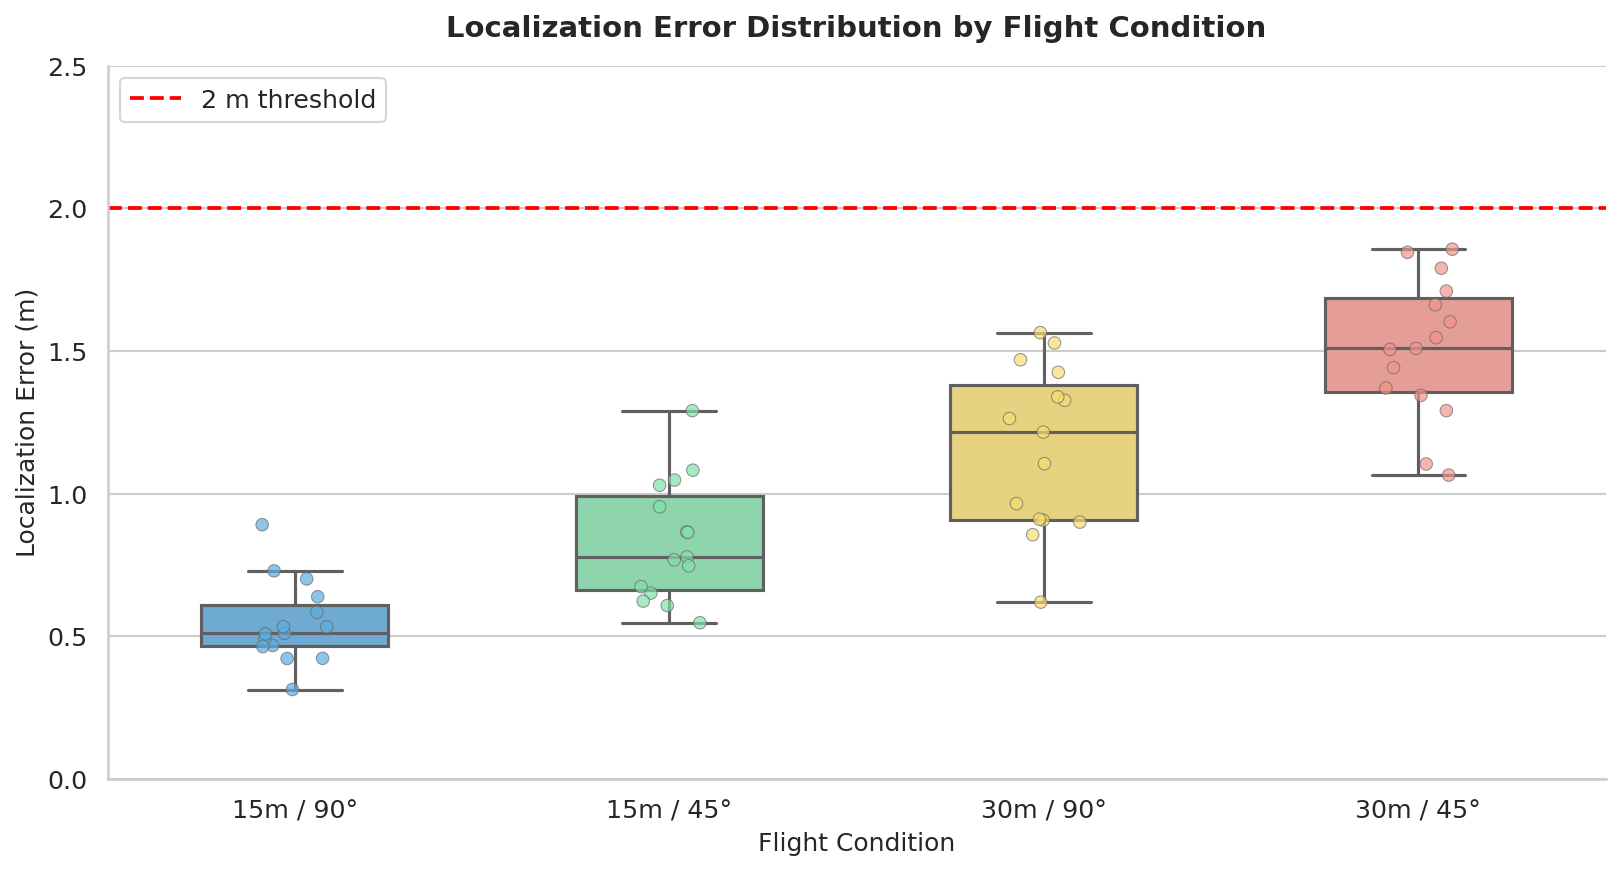

Figure saved -> error_distribution.png


In [ ]:
CONDITION_ORDER = ['15m / 90°', '15m / 45°', '30m / 90°', '30m / 45°']
PALETTE = ['#5DADE2', '#82E0AA', '#F7DC6F', '#F1948A']

sns.set_theme(style='whitegrid', font_scale=1.1)
fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

sns.boxplot(
    data=results, x='Condition', y='Error_m',
    order=CONDITION_ORDER,
    hue='Condition', hue_order=CONDITION_ORDER,
    palette=PALETTE, width=0.5, linewidth=1.5,
    showfliers=False, legend=False, ax=ax
)
sns.stripplot(
    data=results, x='Condition', y='Error_m',
    order=CONDITION_ORDER,
    hue='Condition', hue_order=CONDITION_ORDER,
    palette=PALETTE, size=6, alpha=0.7,
    jitter=True, edgecolor='dimgray', linewidth=0.5,
    legend=False, ax=ax
)

ax.axhline(2.0, color='red', linestyle='--', linewidth=1.8, label='2 m threshold')
ax.set_title('Localization Error Distribution by Flight Condition',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Flight Condition', fontsize=12)
ax.set_ylabel('Localization Error (m)', fontsize=12)
ax.set_ylim(0, 2.5)
ax.legend(loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved -> error_distribution.png")

# **Mean Error vs Altitude & Camera Angle**

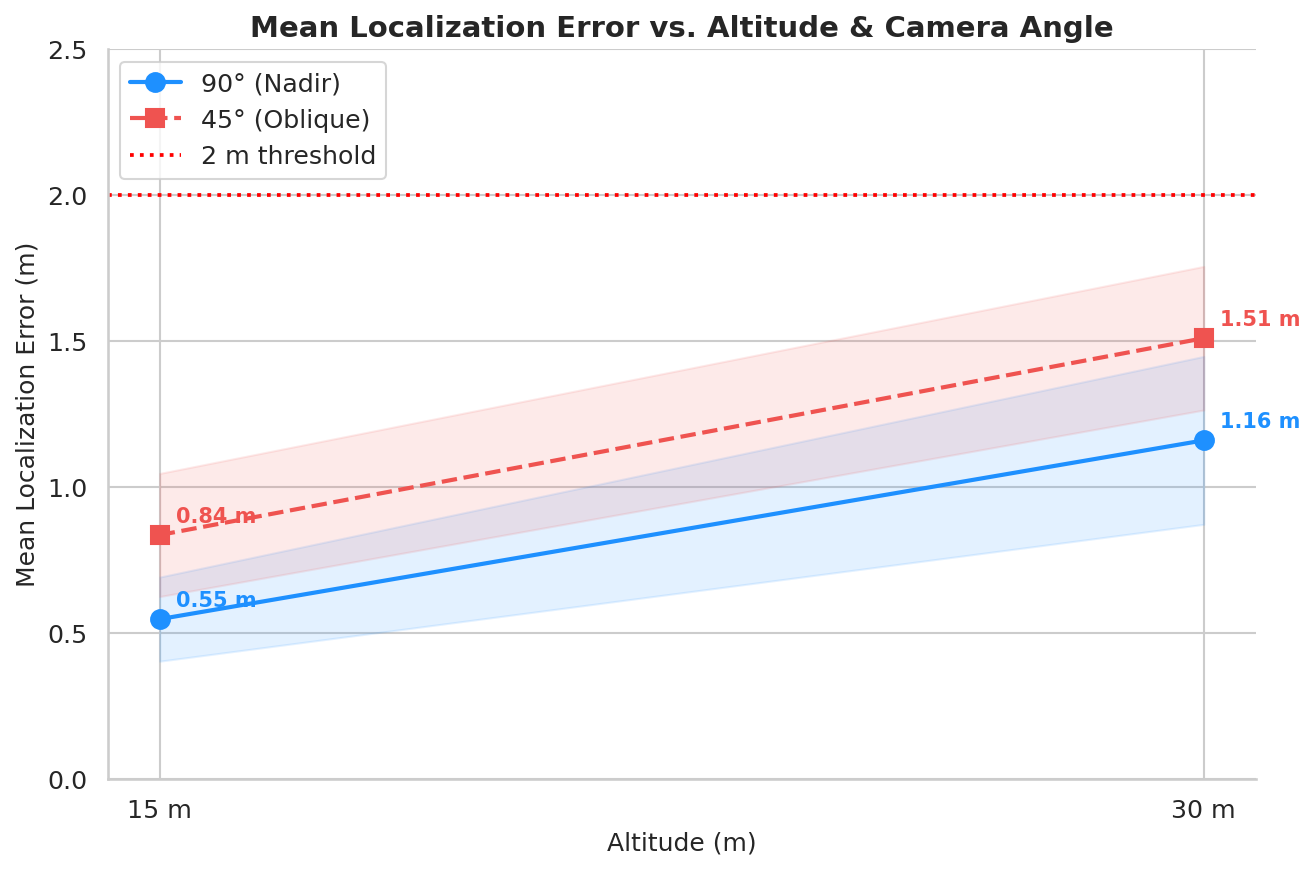

Figure saved -> error_vs_altitude_angle.png


In [ ]:
results['Altitude'] = results['Condition'].str.extract(r'(\d+)m').astype(int)
results['Angle']    = results['Condition'].apply(
    lambda x: '90° (Nadir)' if '90°' in x else '45° (Oblique)'
)

ANGLE_COLORS  = {'90° (Nadir)': '#1E90FF', '45° (Oblique)': '#EF5350'}
ANGLE_MARKERS = {'90° (Nadir)': 'o',       '45° (Oblique)': 's'}
ANGLE_LINES   = {'90° (Nadir)': '-',       '45° (Oblique)': '--'}

sns.set_theme(style='whitegrid', font_scale=1.1)
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

for angle in ['90° (Nadir)', '45° (Oblique)']:
    grp = results[results['Angle'] == angle].groupby('Altitude')['Error_m'].agg(['mean', 'std'])
    alts = grp.index.tolist()
    x_pos = range(len(alts))

    ax.plot(x_pos, grp['mean'],
            marker=ANGLE_MARKERS[angle],
            linestyle=ANGLE_LINES[angle],
            color=ANGLE_COLORS[angle],
            linewidth=2, markersize=9,
            label=angle)

    ax.fill_between(x_pos,
                    grp['mean'] - grp['std'],
                    grp['mean'] + grp['std'],
                    color=ANGLE_COLORS[angle], alpha=0.12)

    for i, (alt, row_g) in enumerate(grp.iterrows()):
        ax.annotate(f"{row_g['mean']:.2f} m",
                    xy=(i, row_g['mean']),
                    xytext=(8, 6), textcoords='offset points',
                    color=ANGLE_COLORS[angle], fontweight='bold', fontsize=10)

ax.axhline(2.0, color='red', linestyle=':', linewidth=1.8, label='2 m threshold')
ax.set_title('Mean Localization Error vs. Altitude & Camera Angle',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Altitude (m)', fontsize=12)
ax.set_ylabel('Mean Localization Error (m)', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['15 m', '30 m'])
ax.set_ylim(0, 2.5)
ax.legend(loc='upper left', frameon=True)

sns.despine()
plt.tight_layout()
plt.savefig('error_vs_altitude_angle.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved -> error_vs_altitude_angle.png")

# **Export Results to Excel**

In [ ]:
OUTPUT_FILE = 'data/geolocation_results.xlsx'

summary_export = (
    results.groupby('Condition')['Error_m']
    .agg(N='count', Mean_Error_m='mean', Std_Dev_m='std',
         Min_m='min', Max_m='max')
    .round(4)
    .reset_index()
)

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    results.to_excel(writer, sheet_name='All_Detections', index=False)
    summary_export.to_excel(writer, sheet_name='Summary', index=False)

print(f"Saved -> {OUTPUT_FILE}")
print(f"Sheet 1 : All_Detections : {len(results)} rows")
print(f"Sheet 2 : Summary        : {len(summary_export)} conditions")

Saved -> data/geolocation_results.xlsx
Sheet 1 : All_Detections : 60 rows
Sheet 2 : Summary        : 4 conditions


## **Interactive Map (Folium)**




In [ ]:
import folium

# Build map centered on the ground truth target — high zoom, standard OSM tiles
m = folium.Map(location=[GT_LAT, GT_LON], zoom_start=19,
               max_zoom=25)

# Ground truth marker
folium.Marker(
    [GT_LAT, GT_LON],
    tooltip='Ground Truth (Target)',
    icon=folium.Icon(color='black', icon='flag')
).add_to(m)

# Color per condition
COND_COLORS = {
    '15m / 90°': '#1E90FF',
    '15m / 45°': '#2ECC71',
    '30m / 90°': '#F39C12',
    '30m / 45°': '#E74C3C'
}

for _, row in results.iterrows():
    color = COND_COLORS.get(row['Condition'], 'blue')

    # Estimated position
    folium.CircleMarker(
        location=[row['Estimated_Lat'], row['Estimated_Lon']],
        radius=6, color=color, fill=True, fill_opacity=0.8,
        tooltip=f"{row['Condition']} | Frame {row['Frame']} | Error: {row['Error_m']:.2f} m"
    ).add_to(m)

    # Drone position (smaller, hollow)
    folium.CircleMarker(
        location=[row['Drone_Lat'], row['Drone_Lon']],
        radius=3, color='orange', fill=False,
        tooltip=f"Drone — {row['Condition']} Frame {row['Frame']}"
    ).add_to(m)

    # Line from drone to estimated position
    folium.PolyLine(
        locations=[[row['Drone_Lat'], row['Drone_Lon']],
                   [row['Estimated_Lat'], row['Estimated_Lon']]],
        color='gray', weight=1, opacity=0.4
    ).add_to(m)

# Simple legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:10px 14px; border-radius:8px;
            font-size:13px; border:1px solid #ccc; line-height:1.8;">
  <b>Conditions</b><br>
  <span style="color:#1E90FF">●</span> 15 m / 90° (Nadir)<br>
  <span style="color:#2ECC71">●</span> 15 m / 45° (Oblique)<br>
  <span style="color:#F39C12">●</span> 30 m / 90° (Nadir)<br>
  <span style="color:#E74C3C">●</span> 30 m / 45° (Oblique)<br>
  <span style="color:orange">●</span> Drone positions<br>
  ⬛ Ground truth target
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('geolocation_map.html')
print("Map saved -> geolocation_map.html")
m   # Renders inline in Colab

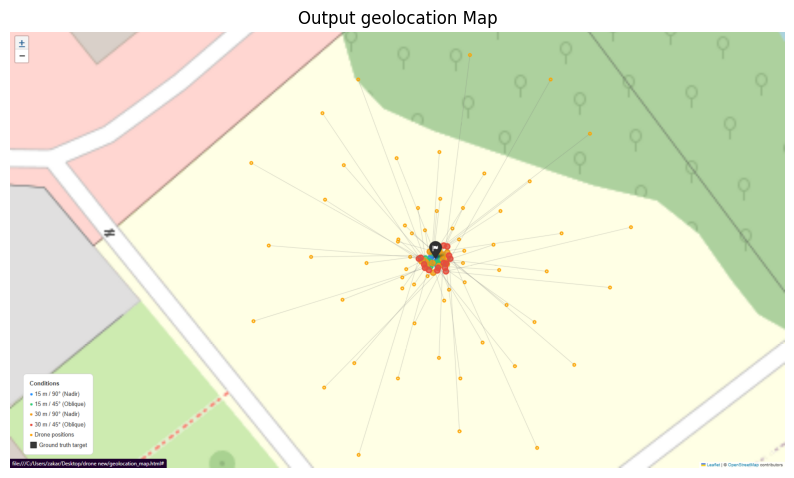

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_path = '/content/geolocation_map.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title('Output geolocation Map')
    plt.axis('off') # Hide axes ticks
    plt.show()
else:
    print(f"Error: Image not found at {image_path}")
